In [314]:
pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


In [315]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils import data
import time
from collections import defaultdict

import json

In [316]:
df = torch.load(r'/kaggle/input/hetero-data5/heterodata_object (5).pt', weights_only=False,map_location=torch.device('cpu'))
df

HeteroData(
  item={
    x=[12101, 768],
    text=[1, 12101, 2],
    is_train=[12101],
    related_ids=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [317]:
df['item'].x[:10]

tensor([[-0.0020,  0.0559,  0.0467,  ..., -0.0266, -0.0212,  0.0599],
        [ 0.0347,  0.0356,  0.0489,  ..., -0.0100, -0.0119,  0.0462],
        [-0.0374,  0.0436,  0.0224,  ..., -0.0174, -0.0035,  0.0502],
        ...,
        [ 0.0076,  0.0215,  0.0153,  ..., -0.0175,  0.0196,  0.0448],
        [ 0.0307,  0.0507,  0.0417,  ..., -0.0147, -0.0342,  0.0302],
        [ 0.0363,  0.0548,  0.0474,  ..., -0.0196, -0.0520,  0.0439]])

In [318]:
(df['item'].x[0] - df['item'].x[1])[:10]

tensor([-0.0367,  0.0203, -0.0022, -0.0191,  0.0341,  0.0390,  0.0106,  0.0390,
        -0.0048,  0.0417])

In [319]:
x = df['item'].x
x.mean(), x.std()

(tensor(-4.0182e-05), tensor(0.0361))

In [320]:
df['item'].x[0]

tensor([-2.0492e-03,  5.5916e-02,  4.6725e-02, -3.1016e-02, -9.1565e-03,
        -7.9645e-02, -7.8061e-02,  8.5023e-02,  2.2042e-02, -1.8758e-02,
         1.9894e-02,  2.4373e-02, -6.7749e-02, -1.0936e-01, -9.2972e-03,
         2.1258e-02,  4.3362e-02, -1.9464e-02,  2.9859e-03, -8.6245e-05,
        -1.3698e-02, -2.0136e-02, -8.3014e-03,  2.3486e-02, -1.4272e-02,
        -5.8928e-02,  6.6698e-02,  2.9907e-02, -4.1057e-02, -4.8138e-02,
         3.1036e-02, -4.9202e-02,  1.6382e-02, -2.2519e-02, -2.2694e-03,
         2.9824e-02, -6.0160e-04, -5.4096e-02,  2.5868e-02, -5.5947e-02,
        -2.6389e-02,  4.2051e-02,  6.1357e-02, -6.3015e-02,  6.1113e-02,
         1.1424e-02,  3.5219e-05, -1.9813e-02,  1.6041e-02, -1.0198e-02,
        -5.1778e-02, -2.3250e-02,  4.3158e-03, -1.6060e-02,  3.2318e-02,
        -2.6336e-02, -2.4691e-02, -9.5121e-04, -9.6187e-03,  2.1069e-02,
        -2.3840e-03,  2.8226e-02, -2.6610e-02,  5.4346e-03,  6.0585e-03,
        -9.0786e-03,  7.8690e-02,  2.2622e-02,  3.0

In [321]:
df['item'].x.shape

torch.Size([12101, 768])

In [322]:
df['item'].text

array([[[0,
         "Title: OPI Nail Lacquer, Simmer and Shimmer, 0.5-Fluid Ounce; Brand: OPI; Categories: ['Beauty', 'Makeup', 'Nails', 'Nail Polish']; Price: 12.0; "],
        [1,
         "Title: OPI Red Shatter Crackle Nail Polish E55 New; Brand: OPI; Categories: ['Beauty', 'Makeup', 'Nails', 'Nail Polish']; Price: 3.04; "],
        [2,
         "Title: SKIN79 The Prestige Beblesh Balm BB Cream Diamond Collection; Brand: Unknown; Categories: ['Beauty', 'Skin Care', 'Face', 'Creams & Moisturizers']; Price: 14.96; "],
        ...,
        [12098,
         "Title: Anti Aging All In One Facial Treatment (Replaces Toner) + The Active Ingredients Heal &amp; Restore While Synergizing With Other Treatments &amp; Serums Layered On Top Of It + Amino Acids, Vitamin C, Matrixyl 3000, &amp; Active Plant Extracts Work Miracles With Existing Sun Damage, Fine Lines, &amp; Especially Skin Discoloration &amp; Uneven Skin Tone + Use Along With Our Complete Anti Aging / Antioxidant Combination System

#### It is our embeddings

In [323]:
class Data_Embeddings(Dataset):
    def __init__(self, data, related):
        super().__init__()
        self.data = data
        self.related = related
        
    def __getitem__(self, index):
        related_items = self.related[index]
        if len(related_items) == 0:
            related_item = self.data[index]
        else:
            related_item = self.data[torch.randint(len(related_items), (1,)).item()]
        return self.data[index], related_item
        
    def __len__(self):
        return self.data.shape[0]

In [324]:
embeds = df['item'].x
related = df['item'].related_ids
ds = Data_Embeddings(embeds,related)

In [325]:
train_rq, val_rq = data.random_split(ds, [0.9, 0.1])
print(len(val_rq))

1210


In [326]:
dl_train_rq = DataLoader(train_rq, batch_size = 1024, shuffle = True)
dl_val_rq = DataLoader(val_rq, batch_size = len(val_rq), shuffle= False)

In [327]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [328]:
class MLP(nn.Module):
    def __init__(self, input_size,  hidden_sizes, output_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.enc = nn.Sequential()
        dims = [self.input_size] + self.hidden_sizes + [self.output_size]
        for i, (inp, out) in enumerate(zip(dims[:-1], dims[1:])):
            self.enc.append(nn.Linear(inp, out, bias = False))
            if i != len(dims)-2:
                self.enc.append(nn.ReLU())
                
         
    def forward(self, X):
        return self.enc(X)


In [329]:
class Quantize_Loss(nn.Module):
    def __init__(self, beta_weight : float):
        super().__init__()
        self.beta_weight = beta_weight
    def forward(self, query, value):
        emb_loss  = F.mse_loss(query.detach(), value) * query.shape[1]
        query_loss =  F.mse_loss(query,value.detach())* query.shape[1]
        return emb_loss + self.beta_weight * query_loss
        
class Quantize(nn.Module):
    def __init__(self, n_embed, embed_dim, beta_weight=0.25, proj = False):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_embed = n_embed
        self.beta_weight = beta_weight
        self.embedding = nn.Embedding(n_embed, embed_dim)
        self.loss_fn = Quantize_Loss(beta_weight)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False) if proj else nn.Identity()

    def forward(self, x):
        codebook = self.out_proj(self.embedding.weight)
        dist = (
            (x**2).sum(1, keepdim=True)
            + (codebook**2).sum(1)
            - 2 * x @ codebook.T
        )
        ids = dist.argmin(dim=1)
        emb = self.out_proj(self.embedding(ids))
        emb_out = x + (emb - x).detach()
        loss = self.loss_fn(x, emb)
        return emb_out, ids, loss
            


In [330]:
class RqVae(nn.Module):
    def __init__(self, input_size,  hidden_sizes, n_embed, embed_dim, n_layers,  beta_weight=0.25, proj = False):
        super().__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.embed_dim = embed_dim
        self.beta_weight = beta_weight
        self.encoder = MLP(input_size,  hidden_sizes, embed_dim)
        self.decoder = MLP(embed_dim, hidden_sizes[-1::-1], input_size)
        self.layers = nn.ModuleList(modules = [Quantize(n_embed, embed_dim, beta_weight, proj) for i in range(n_layers)])

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)
   
    
    def forward(self, x):
        res = self.encode(x)
        quantize_loss = 0
        embs, residuals, sem_ids = [], [], []
        for quant in self.layers:
            residuals.append(res)
            emb_out, sids, q_loss = quant(res)
            quantize_loss += q_loss
            res = res - emb_out
            sem_ids.append(sids)
            embs.append(emb_out)
        x_hat = self.decode(sum(embs))
        rec_loss = F.mse_loss(x, x_hat) * x.shape[1]
        loss = rec_loss + quantize_loss
        return {
            "x_hat": x_hat,
            "sids": sem_ids,
            "embs": embs,
            "q_loss": quantize_loss,
            "r_loss": rec_loss,
            "loss": loss
        }
                

In [331]:
class RqVaePLUM(nn.Module):
    def __init__(self,input_size, hidden_sizes, embed_dim,n_layers, beta_weight=0.25,  proj=False):
        super().__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.embed_dim = embed_dim
        self.beta_weight = beta_weight
        self.encoder = MLP(input_size, hidden_sizes, embed_dim)
        self.decoder = MLP(embed_dim, hidden_sizes[-1::-1], input_size)
        self.layers = nn.ModuleList([
            Quantize(2048//(2**(lvl-1)), embed_dim, beta_weight, proj)
            for lvl in range(1, n_layers+1)])

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)
        
    def forward(self, x, relative):
        res = self.encode(x)
        rel_res = self.encode(relative)
        concs = torch.cat([res, rel_res], dim=0)
        quantize_loss = 0.0
        sid_loss = 0.0
        z_sum = 0
        embs = []
        sids = []
        r = torch.randint(low = 1, high = len(self.layers)+1, size=(1, )).item()
        for lvl, quant in enumerate(self.layers):
            emb_out, sid, q_loss = quant(res)
            msk = lvl < r
            quantize_loss += q_loss
            res = res - emb_out
            z_sum += emb_out * msk
            embs.append(emb_out)
            sids.append(sid)
        x_hat = self.decode(z_sum)
        rec_loss = F.mse_loss(x_hat, x) * x.shape[1]
        concs = F.normalize(concs, dim=1)
        sim = (concs @ concs.T)
        num = torch.exp(torch.diagonal(sim))
        denum = torch.sum(torch.exp(sim), dim = 1)
        mask = torch.eye(concs.shape[0], device = device).bool()
        sim.masked_fill_(mask, -1e9)
        con_loss =  -(torch.log(num/denum)).sum()
        total_loss = (rec_loss+ quantize_loss + con_loss)
        return {
            "x_hat": x_hat,
            "sids": sids,
            "embs": embs,
            "q_loss": quantize_loss,
            "r_loss": rec_loss,
            "con_loss": con_loss,
            "loss": total_loss
        }


In [332]:
def unique_per_level(SIDs):
    uns = []
    for sid in SIDs:
        uns.append(sid.unique().numel())
    return torch.tensor(uns, device = device)

In [333]:
lr = 0.4
n_ep = 5000
n_layers = 3
rq_vae = RqVae(x.shape[1], [512,256, 128], 256, 32, n_layers,beta_weight=0.25, proj= True)
plum = RqVaePLUM(x.shape[1], [512, 256, 128], 32, n_layers, beta_weight=0.25, proj = True)
rq_vae = rq_vae.to(device)
plum = plum.to(device)
optimizer_rqvae = optim.Adagrad(rq_vae.parameters(), lr =lr)
optimizer_plum = optim.Adagrad(plum.parameters(), lr =lr)
history_rqvae = {
    'train_total_loss':[],
    'train_recon_loss':[],
    'train_rq_loss':[],
    'train_sids_num':[],
    'val_total_loss':[],
    'val_recon_loss':[],
    'val_rq_loss':[],
    'val_sids_num':[]}
history_plum = {
    'train_total_loss':[],
    'train_recon_loss':[],
    'train_rq_loss':[],
    'train_sids_num':[],
    'val_total_loss':[],
    'val_recon_loss':[],
    'val_rq_loss':[],
    'val_sids_num':[]}

In [ ]:
for e in range(n_ep): 
    rq_vae.train()
    plum.train()
    loss_total_avg_rq = 0 
    loss_recon_avg_rq = 0 
    loss_rq_avg_rq = 0 
    loss_total_avg_plum = 0
    loss_recon_avg_plum = 0
    loss_rq_avg_plum = 0
    loss_con_avg_plum = 0
    sids_un_avg_rq = torch.zeros(n_layers, device = device)
    sids_un_avg_plum = torch.zeros(n_layers, device = device)
    train_tqdm = tqdm(dl_train_rq, leave = True, desc=f'train {e+1}/{n_ep}') 
    for emb, related in train_tqdm:
        related = related.to(device)
        emb = emb.to(device)
        pred = rq_vae(emb) 
        x_hat, sids, encoded, q_loss_rq, r_loss, loss, = pred['x_hat'],pred['sids'], pred['embs'], pred['q_loss'], pred['r_loss'], pred['loss']
        loss_recon_rq = r_loss
        total_loss_rq = loss
        sids_un_rq=unique_per_level(sids)
        
        optimizer_rqvae.zero_grad() 
        total_loss_rq.backward() 
        optimizer_rqvae.step() 
        loss_total_avg_rq += total_loss_rq.item()
        loss_recon_avg_rq += loss_recon_rq.item()
        loss_rq_avg_rq += q_loss_rq.item() 
        sids_un_avg_rq += sids_un_rq
        
        pred_plum = plum(emb, related)
        x_hat, sids, encoded, q_loss_pl, r_loss, con_loss, loss, = pred_plum['x_hat'],pred_plum['sids'], pred_plum['embs'], pred_plum['q_loss'], pred_plum['r_loss'], pred_plum['con_loss'], pred_plum['loss']
        loss_recon_pl = r_loss
        total_loss_pl = loss
        sids_un_pl=unique_per_level(sids)
        
        train_tqdm.set_postfix( total=f"{total_loss_rq.item():.3f}", quant=f"{q_loss_rq.item():.3f}", recon=f"{loss_recon_rq.item():.3f}", 
                               uniqs = f"{sids_un_rq.tolist()}") 
        optimizer_plum.zero_grad() 
        total_loss_pl.backward() 
        optimizer_plum.step() 
        loss_total_avg_plum += total_loss_pl.item()
        loss_recon_avg_plum += loss_recon_pl.item()
        loss_rq_avg_plum += q_loss_pl.item() 
        loss_con_avg_plum += con_loss.item()
        sids_un_avg_plum += sids_un_pl
        
    loss_total_avg_rq = loss_total_avg_rq/ len(dl_train_rq) 
    loss_recon_avg_rq = loss_recon_avg_rq/ len(dl_train_rq) 
    loss_rq_avg_rq = loss_rq_avg_rq/ len(dl_train_rq) 
    sids_un_avg_rq = sids_un_avg_rq/len(dl_train_rq)
    
    loss_total_avg_plum = loss_total_avg_plum/ len(dl_train_rq) 
    loss_recon_avg_plum = loss_recon_avg_plum/ len(dl_train_rq) 
    loss_rq_avg_plum = loss_rq_avg_plum/ len(dl_train_rq) 
    loss_con_avg_plum = loss_con_avg_plum/len(dl_train_rq)
    sids_un_avg_plum = sids_un_avg_plum/len(dl_train_rq)
    tqdm.write(
        f"PLUM train| total={loss_total_avg_plum:.4f} "
        f"quant={loss_rq_avg_plum:.4f} "
        f"recon={loss_recon_avg_plum:.4f} "
        f"con={loss_con_avg_plum:.4f} "
        f"uniq={sids_un_avg_plum.tolist()}"
    )    
    print(sids_un_avg_rq, sids_un_avg_plum)
    
    history_rqvae['train_total_loss'].append(loss_total_avg_rq) 
    history_rqvae['train_recon_loss'].append(loss_recon_avg_rq)
    history_rqvae['train_rq_loss'].append(loss_rq_avg_rq) 
    history_rqvae['train_sids_num'].append(sids_un_avg_rq)
    history_plum['train_total_loss'].append(loss_total_avg_plum) 
    history_plum['train_recon_loss'].append(loss_recon_avg_plum)
    history_plum['train_rq_loss'].append(loss_rq_avg_plum) 
    history_plum['train_sids_num'].append(sids_un_avg_plum)
    
    rq_vae.eval() 
    plum.eval()
    val_tqdm = tqdm(dl_val_rq, leave=True, desc = f'val {e+1}/{n_ep}') 
    loss_total_avg_rq = 0 
    loss_recon_avg_rq = 0 
    loss_rq_avg_rq = 0
    loss_total_avg_plum = 0
    loss_recon_avg_plum = 0
    loss_rq_avg_plum = 0
    loss_con_avg_plum = 0
    sids_un_avg_rq = torch.zeros(n_layers, device=device)
    sids_un_avg_plum = torch.zeros(n_layers,device=device)
    with torch.no_grad(): 
        for  emb,related in val_tqdm:
            related = related.to(device)
            emb = emb.to(device) 
            pred = rq_vae(emb) 
            x_hat, sids, encoded, q_loss_rq, r_loss, loss= pred['x_hat'],pred['sids'], pred['embs'], pred['q_loss'], pred['r_loss'], pred['loss']
            loss_recon_rq = r_loss
            sids_un_rq=unique_per_level(sids)
            total_loss_rq = loss
            
            
            loss_total_avg_rq += total_loss_rq.item()
            loss_recon_avg_rq += loss_recon_rq.item()
            loss_rq_avg_rq += q_loss_rq.item()
            sids_un_avg_rq += sids_un_rq
            
            pred_plum = plum(emb, related)
            x_hat, sids, encoded, q_loss_pl, r_loss, con_loss, loss = pred_plum['x_hat'],pred_plum['sids'], pred_plum['embs'], pred_plum['q_loss'], pred_plum['r_loss'], pred_plum['con_loss'], pred_plum['loss']
            loss_recon_pl = r_loss
            total_loss_pl = loss
            sids_un_pl=unique_per_level(sids)
            
            val_tqdm.set_postfix( total=f"{total_loss_rq.item():.3f}", quant=f"{q_loss_rq.item():.3f}", recon=f"{loss_recon_rq.item():.3f}", 
                               uniqs = f"{sids_un_rq.tolist()}") 
            loss_total_avg_plum += total_loss_pl.item()
            loss_recon_avg_plum += loss_recon_pl.item()
            loss_con_avg_plum += con_loss.item()
            loss_rq_avg_plum += q_loss_pl.item() 
            sids_un_avg_plum += sids_un_pl
            
        loss_total_avg_rq = loss_total_avg_rq/ len(dl_val_rq) 
        loss_recon_avg_rq = loss_recon_avg_rq/ len(dl_val_rq)
        loss_rq_avg_rq = loss_rq_avg_rq/ len(dl_val_rq)
        sids_un_avg_rq = sids_un_avg_rq/len(dl_val_rq)

        loss_total_avg_plum = loss_total_avg_plum/ len(dl_val_rq) 
        loss_recon_avg_plum = loss_recon_avg_plum/ len(dl_val_rq) 
        loss_rq_avg_plum = loss_rq_avg_plum/ len(dl_val_rq) 
        loss_con_avg_plum = loss_con_avg_plum/len(dl_val_rq)
        sids_un_avg_plum = sids_un_avg_plum/len(dl_val_rq)
        
        tqdm.write(f"PLUM val| total={loss_total_avg_plum:.4f} "
                    f"q={loss_rq_avg_plum:.4f} "
                    f"rec={loss_recon_avg_plum:.4f} "
                    f"con={loss_con_avg_plum:.4f} "
                    f"uniq={sids_un_avg_plum.tolist()}"
        )
        
        history_rqvae['val_total_loss'].append(loss_total_avg_rq) 
        history_rqvae['val_recon_loss'].append(loss_recon_avg_rq) 
        history_rqvae['val_rq_loss'].append(loss_rq_avg_rq) 
        history_rqvae['val_sids_num'].append(sids_un_avg_rq) 
        history_plum['val_total_loss'].append(loss_total_avg_plum) 
        history_plum['val_recon_loss'].append(loss_recon_avg_plum)
        history_plum['val_rq_loss'].append(loss_rq_avg_plum) 
        history_plum['val_sids_num'].append(sids_un_avg_plum)

train 1/5000: 100%|██████████| 11/11 [00:00<00:00, 36.25it/s, quant=140.417, recon=3474131456.000, total=3474131712.000, uniqs=[4, 5, 6]]                 


PLUM train| total=43584920587692.5781 quant=798951327478.2690 recon=42785970274129.5703 con=14948.3821 uniq=[5.909090995788574, 6.909090995788574, 8.181818008422852]
tensor([5.3636, 5.8182, 6.4545], device='cuda:0') tensor([5.9091, 6.9091, 8.1818], device='cuda:0')


val 1/5000: 100%|██████████| 1/1 [00:00<00:00, 39.91it/s, quant=168.747, recon=33414094848.000, total=33414094848.000, uniqs=[3, 6, 4]]


PLUM val| total=101743689728.0000 q=601873.0000 rec=101743075328.0000 con=18371.5977 uniq=[24.0, 24.0, 42.0]


train 2/5000: 100%|██████████| 11/11 [00:00<00:00, 35.31it/s, quant=471.593, recon=6606983528448.000, total=6606983528448.000, uniqs=[8, 6, 7]]  


...

PLUM val| total=4552833.5000 q=979.9108 rec=4533250.0000 con=18603.3867 uniq=[56.0, 143.0, 96.0]


train 1084/5000: 100%|██████████| 11/11 [00:00<00:00, 40.14it/s, quant=27.853, recon=8714.921, total=8742.773, uniqs=[3, 5, 5]] 


PLUM train| total=16533.8355 quant=1681.9938 recon=10.1166 con=14841.7254 uniq=[54.181819915771484, 133.18182373046875, 88.0]
tensor([3.0000, 4.3636, 4.6364], device='cuda:0') tensor([ 54.1818, 133.1818,  88.0000], device='cuda:0')


val 1084/5000: 100%|██████████| 1/1 [00:00<00:00, 45.04it/s, quant=14.726, recon=2478.524, total=2493.250, uniqs=[3, 4, 4]]


PLUM val| total=4550863.5000 q=980.1644 rec=4531307.0000 con=18576.3770 uniq=[55.0, 140.0, 97.0]


### As we know each embedding corresponds to unique item, we can consider every coincident SID as collision

In [382]:
sid_to_id_rq = defaultdict(list)
id_to_sid_rq = {}
sid_to_id_pl = defaultdict(list)
id_to_sid_pl = {}

plum.eval()
rq_vae.eval()

with torch.no_grad():
    for id, (emb, rel) in enumerate(ds):
        emb = emb.view(1, -1).to(device)
        rel = rel.view(1, -1).to(device)

        pred_rq = rq_vae(emb)        
        pred_pl = plum(emb, rel)

        sid_rq = tuple(int(lvl[0].cpu()) for lvl in pred_rq['sids'])
        sid_pl = tuple(int(lvl[0].cpu()) for lvl in pred_pl['sids'])

        sid_to_id_rq[sid_rq].append(id)
        id_to_sid_rq[id] = sid_rq

        sid_to_id_pl[sid_pl].append(id)
        id_to_sid_pl[id] = sid_pl


In [383]:
id_to_fullsid_rq = {}
id_to_fullsid_pl = {}
number_collisions_rq = 0
number_collisions_pl = 0

for sid, ids in sid_to_id_rq.items():
    if len(ids) == 1:
        id_to_fullsid_rq[ids[0]] = sid
    else:
        number_collisions_rq += len(ids) - 1
        for cnt, id in enumerate(sorted(ids)):
            id_to_fullsid_rq[id] = (*sid, cnt)

for sid, ids in sid_to_id_pl.items():
    if len(ids) == 1:
        id_to_fullsid_pl[ids[0]] = sid
    else:
        number_collisions_pl += len(ids) - 1
        for cnt, id in enumerate(sorted(ids)):
            id_to_fullsid_pl[id] = (*sid, cnt)


In [377]:
list(id_to_fullsid_rq.items())[:20]

[(<function id(obj, /)>, (131, 118, 50, 1))]

In [378]:
list(id_to_fullsid_pl.items())[:20]

[(<function id(obj, /)>, (336, 610, 495))]

In [379]:
id_to_fullsid_rq

{<function id(obj, /)>: (131, 118, 50, 1)}

In [389]:
n_unique_sid_rq = len(sid_to_id_rq)
n_unique_sid_pl = len(sid_to_id_pl)
n_collisions_rq = sum(len(v) - 1 for v in sid_to_id_rq.values())
n_collisions_pl = sum(len(v) - 1 for v in sid_to_id_pl.values())
max_cluster_rq = max(len(v) for v in sid_to_id_rq.values())
max_cluster_pl = max(len(v) for v in sid_to_id_pl.values())

cfr_rq = (len(ds) - n_collisions_rq) / len(ds)
cfr_pl = (len(ds) - n_collisions_pl) / len(ds)
stats = pd.DataFrame({
    'unique_base_codes': [len(sid_to_id_rq), len(sid_to_id_pl)],
    'collision_free_ratio': [cfr_rq, cfr_pl],
    'max_cluster_size': [max_cluster_rq, max_cluster_pl],
}, index=['RQ_VAE', 'PLUM'])
stats

,unique_base_codes,collision_free_ratio,max_cluster_size
RQ_VAE,31,0.002562,8615
PLUM,3829,0.316420,442


In [345]:
def plot_losses(history):
    epochs = range(1, len(history["train_total_loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_total_loss"], label="train total")
    plt.plot(epochs, history["val_total_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total loss")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_recon_loss"], label="train recon")
    plt.plot(epochs, history["train_rq_loss"], label="train quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train losses")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_recon_loss"], label="val recon")
    plt.plot(epochs, history["val_rq_loss"], label="val quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Val losses")
    plt.yscale("log")
    plt.legend()

    plt.show()


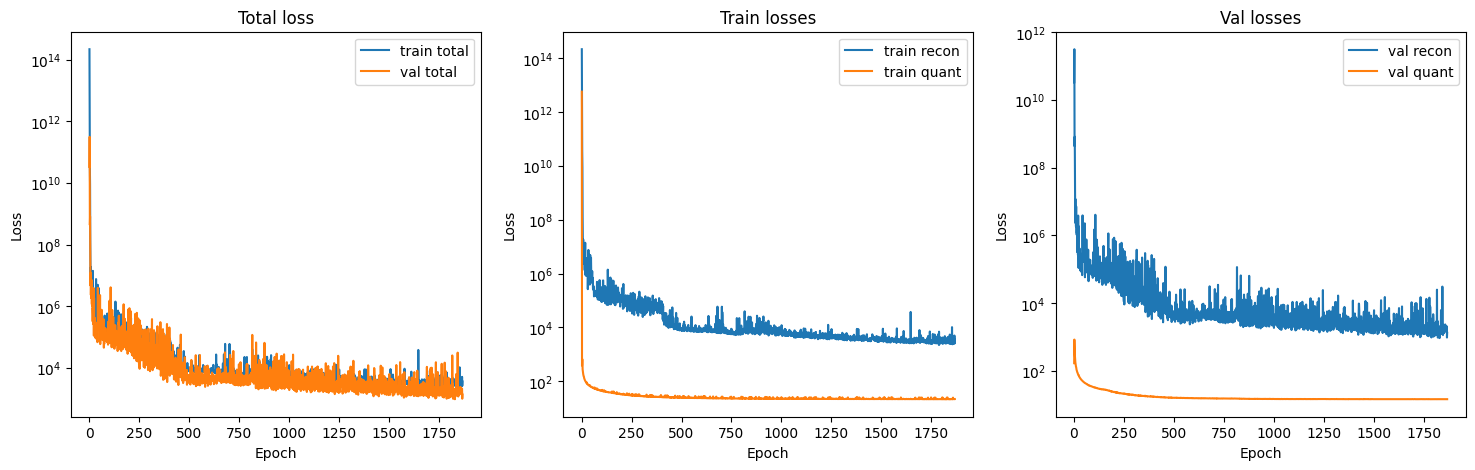

In [346]:
plot_losses(history_rqvae)

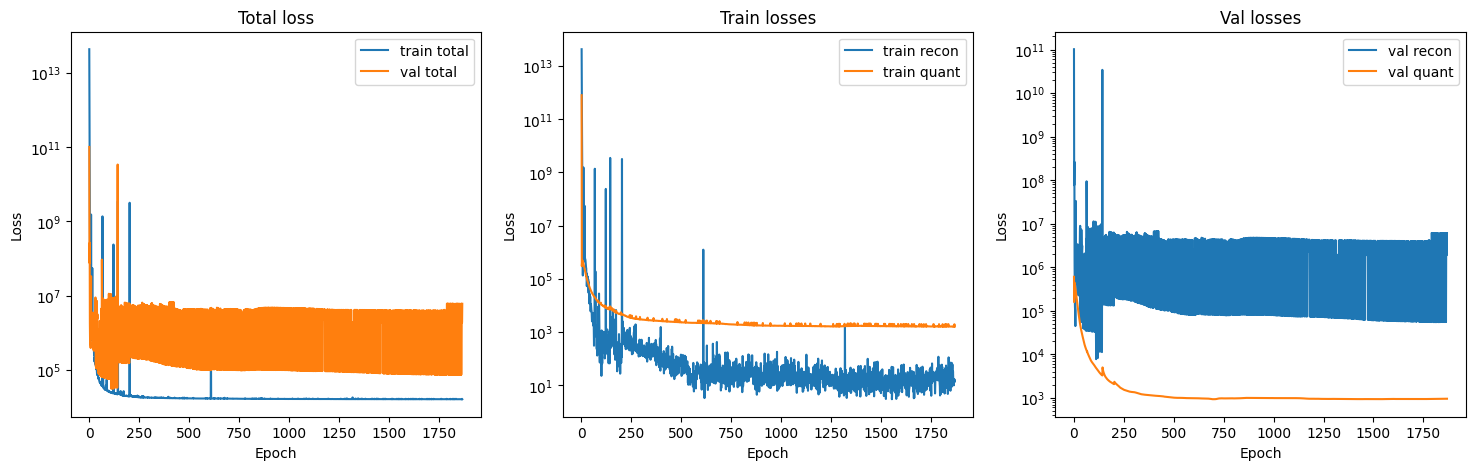

In [347]:
plot_losses(history_plum)

In [369]:
def plot_SIDS(history):
    epochs = range(1, len(history["val_sids_num"]) + 1)
    for i in range(len(history["val_sids_num"])): 
        history["val_sids_num"][i] = history["val_sids_num"][i].cpu()
        history["train_sids_num"][i] = history['train_sids_num'][i].cpu()
    sids_val, sids_train = np.asarray(history["val_sids_num"]), np.asarray(history["train_sids_num"])
    
    plt.figure(figsize= (18, 12))
    for i in range(sids_val.shape[1]):
        plt.subplot(3, 1, i+1)
        
        plt.plot(epochs, sids_train[:, i], label=f"train sids level {i}")
        plt.plot(epochs, sids_val[:, i], label=f"val sids number {i}")
        plt.xlabel("Epoch")
        plt.ylabel("SID number")
        plt.legend()
    plt.show()

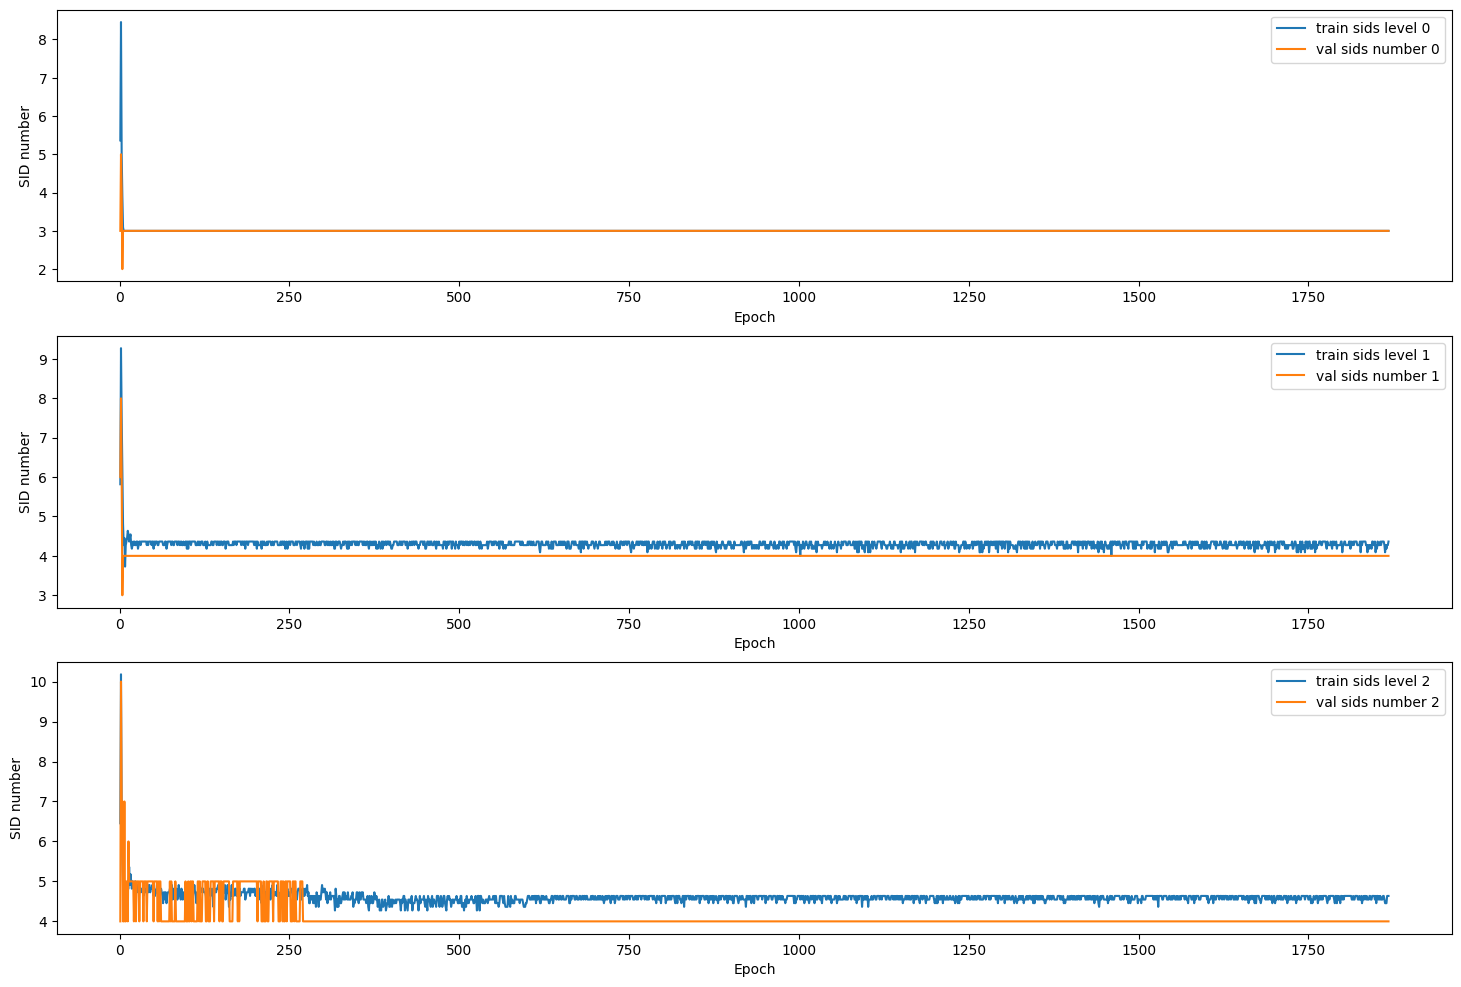

In [370]:
plot_SIDS(history_rqvae)

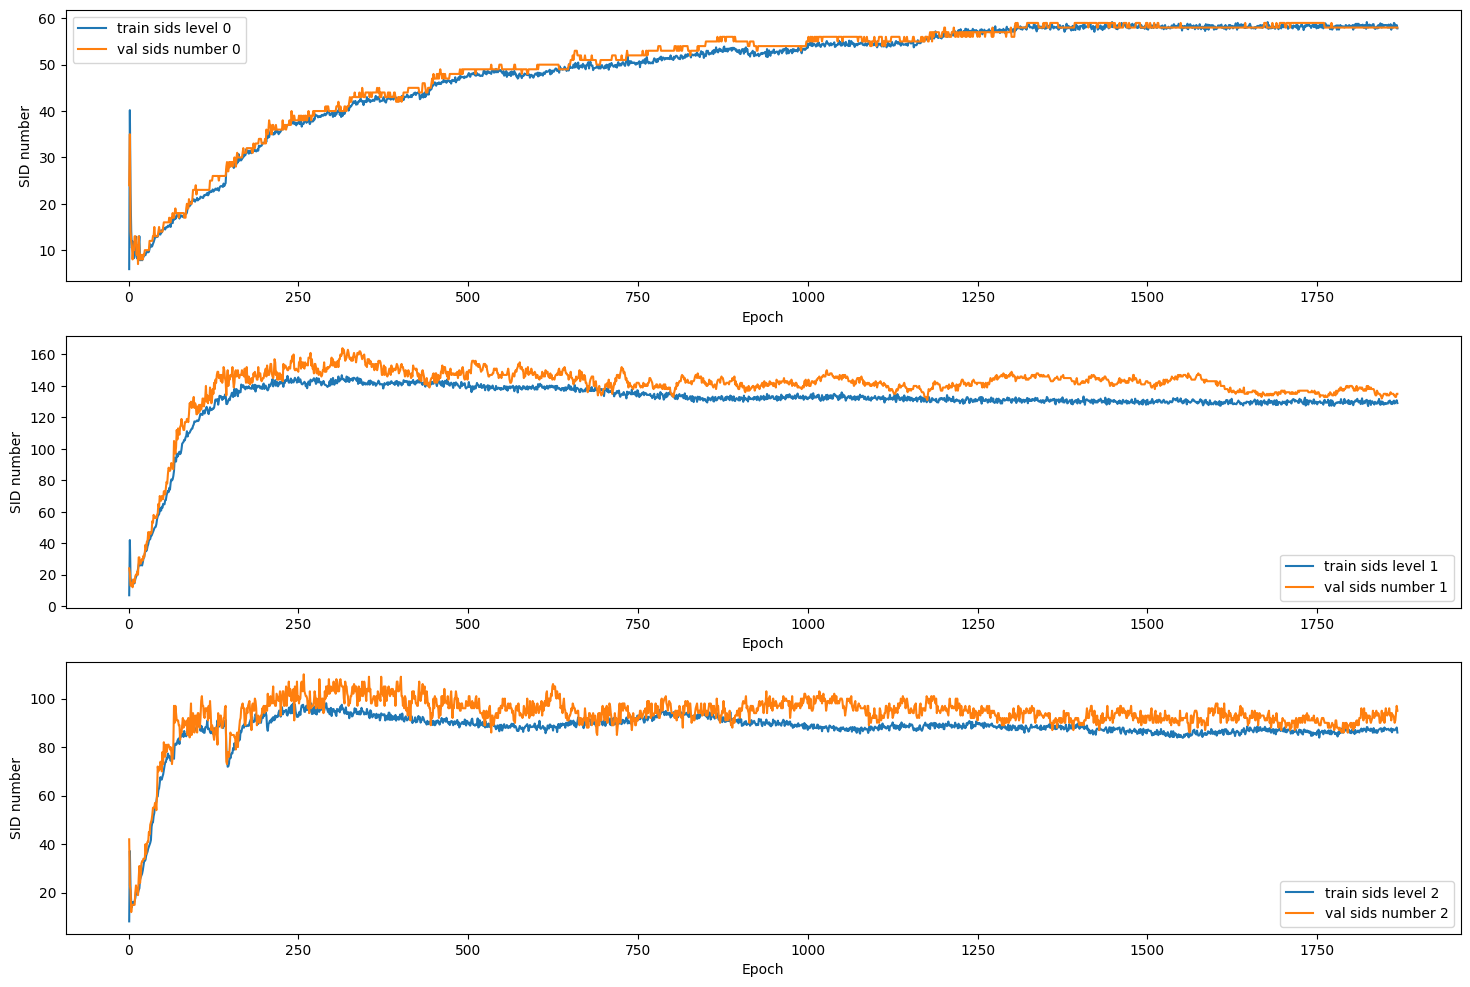

In [371]:
plot_SIDS(history_plum)

torch.save(rq_vae.state_dict(), f = 'rqvae_classic_params.pt')

json.dump(history,open("metrics.json", "w"), indent=2,default=lambda x: x.tolist())